## Задачи для TensorFlow

In [2]:
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import torch
from gensim.models import Word2Vec
from tensorflow.keras.layers import TextVectorization, LayerNormalization, Dropout, GlobalAveragePooling1D, Dense, Conv1D, MaxPooling1D, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import  accuracy_score, f1_score, roc_auc_score, roc_curve, auc
import numpy as np

from scikeras.wrappers import KerasClassifier  # Импортируем SciKerasClassifier
import seaborn as sns
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.initializers import Constant
from sklearn.model_selection import GridSearchCV

In [3]:
stop_words = set(stopwords.words('english'))

df = pd.read_csv('FakeNewsNet.csv')
df = df[['title', 'news_url', 'source_domain', 'real']]

# Проверка наличия пропущенных значений и удаление строк с пропущенными значениями
print(df.isnull().sum())
df.dropna(inplace=True)

print(df['real'].value_counts())

# Объединяем title, news_url и source_domain в один текстовый столбец
df['text'] = df['title'] + ' ' + df['news_url'] + ' ' + df['source_domain']
df = df[['text', 'real']]

# После объединения столбцов еще раз проверка пропущенных значений
print(df.isnull().sum())

title              0
news_url         330
source_domain    330
real               0
dtype: int64
real
1    17371
0     5495
Name: count, dtype: int64
text    0
real    0
dtype: int64


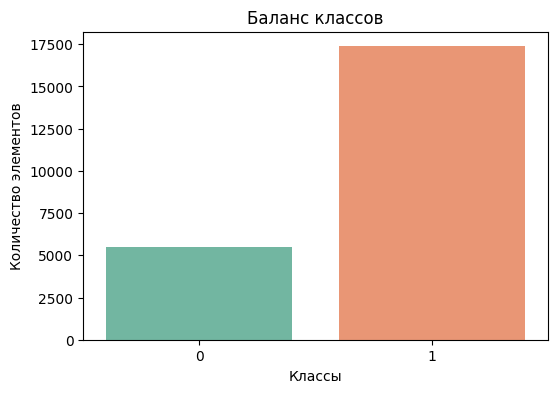

In [4]:
# Количество элементов каждого класса
class_counts = df['real'].value_counts()

# Визуализация графика баланса классов
plt.figure(figsize=(6, 4))
sns.countplot(x='real', data=df, hue='real', palette='Set2', legend=False)
plt.title('Баланс классов')
plt.xlabel('Классы')
plt.ylabel('Количество элементов')
plt.show()

In [5]:
def preprocess_text(text):
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.lower() not in stop_words]
    tokens = [word for word in tokens if word.isalpha()]
    preprocessed_text = ' '.join(tokens)
    return preprocessed_text

def preprocess_dataframe(dataframe, text_column):
    dataframe[text_column] = dataframe[text_column].apply(preprocess_text)
    return dataframe


# Предварительная обработка текстовых данных
df = preprocess_dataframe(df, 'text')

In [6]:
# Определение гиперпараметров
EMBEDDING_DIM = 256 
HIDDEN_DIM = 64    
OUTPUT_DIM = 1
N_EPOCHS = 20
BATCH = 128

# Разделение текста на предложения
sentences = df['text'].apply(lambda x: x.split())

# Обучение модели Word2Vec
w2v_model = Word2Vec(sentences=sentences, vector_size=EMBEDDING_DIM, window=10, min_count=1, workers=8)
w2v_model.build_vocab(sentences)  # Создание словаря модели
w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=15)  # Обучение модели на предложениях
w2v_model.save('w2v_model.txt')  # Сохранение обученной модели

# Загрузка обученной модели Word2Vec
w2v_model = Word2Vec.load('w2v_model.txt')

# Получение вложений слов
word2vec_vectors = w2v_model.wv

# Преобразование вложений слов в тензор TensorFlow
pre_trained_emb = tf.convert_to_tensor(word2vec_vectors.vectors, dtype=tf.float32)

# Добавление строки заполнения
padding_row = tf.zeros([1, EMBEDDING_DIM], dtype=tf.float32) 
pre_trained_emb = tf.concat([pre_trained_emb, padding_row], axis=0)

INPUT_DIM = len(word2vec_vectors.key_to_index) + 1

# Определение максимального размера словаря
max_size = len(w2v_model.wv.key_to_index)

# Создает словарь из num_words наиболее часто встречающихся слов в тексте.
tokenizer = Tokenizer(num_words=max_size)  # Используем max_size, чтобы сохранить все слова из Word2Vec
tokenizer.fit_on_texts(df['text'])

# Преобразует текст в последовательности целых чисел (индексы слов в словаре).
tokenized_text = tokenizer.texts_to_sequences(df['text'])

# Выравнивание последовательностей по длине (паддинг), для передачи в модель
maxlen = max(len(x) for x in tokenized_text)
padded_text = pad_sequences(tokenized_text, maxlen=maxlen)

# Создание Embedding-слоя
embedding_matrix = np.zeros((len(tokenizer.word_index) + 1, w2v_model.vector_size))  # Размер соответствует словарю Tokenizer

# Итерация по словарю "слово: индекс"
for word, i in tokenizer.word_index.items():
    # Если индекс превышает кол-во слов в словаре, то скипаем
    if i > tokenizer.num_words:
        continue
    # Проверяем, существует ли слово в словаре w2v_model.wv
    if word in w2v_model.wv:
        # Получаем вектор соответствущий слову в модели word2vec
        embedding_vector = w2v_model.wv[word]
        # Если слово найдено в словаре токенизатора, то в embedding_matrix проставляем вектор соответствующий слову
        embedding_matrix[i] = embedding_vector
    else:
        # Если слово не найдено, то можно использовать нулевой вектор
        embedding_matrix[i] = np.zeros(w2v_model.vector_size) 


# Embedding слой
embedding_layer = Embedding(
    # Размер словаря
    input_dim = len(tokenizer.word_index) + 1,  # Используем размер словаря Tokenizer
    # Размер вектора вложений
    output_dim = w2v_model.vector_size,
    # Установка весов слоя
    embeddings_initializer = Constant(embedding_matrix),
    # Длина входных последовательностей
    input_length = maxlen,
    # Предотвратит обновление весов во время обучения
    trainable = False
    )


# Разделение данных на обучающую, валидационную и тестовую выборки
X_train, X_val, y_train, y_val = train_test_split(padded_text, df['real'], test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


In [7]:
# Определение диапазонов значений для гиперпараметров
param_grid = {
    'model_type': ['RNN'],  # Добавляем 'model_type' в param_grid
    'EMBEDDING_DIM': [64, 128, 256, 512],
    'HIDDEN_DIM': [32, 64, 128, 256],
    'N_EPOCHS': [10, 20, 30],
    'BATCH': [8, 16, 32, 64, 128],
    'Dropout': [0.1, 0.2, 0.3]
}

In [8]:
def create_model(model_type, EMBEDDING_DIM, HIDDEN_DIM, N_EPOCHS, BATCH, Dropout):
    if model_type == 'RNN':
        model_layer = tf.keras.layers.RNN(tf.keras.layers.SimpleRNNCell(HIDDEN_DIM), return_sequences=False)
    elif model_type == 'LSTM':
        model_layer = tf.keras.layers.LSTM(HIDDEN_DIM, return_sequences=False)
    elif model_type == 'GRU':
        model_layer = tf.keras.layers.GRU(HIDDEN_DIM, return_sequences=False)
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    model = tf.keras.Sequential([
        embedding_layer,
        model_layer,
        tf.keras.layers.Dropout(Dropout),
        LayerNormalization(),
        Dense(OUTPUT_DIM, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
model = KerasClassifier(
    model=create_model,  # Передаем функцию create_model 
    model_type='RNN', # Задаем тип модели
    EMBEDDING_DIM=EMBEDDING_DIM, 
    HIDDEN_DIM=HIDDEN_DIM, 
    N_EPOCHS=N_EPOCHS,
    BATCH=BATCH,
    Dropout=Dropout,
    verbose=3
)

# Инициализация GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3)  # cv=3 - 3-кратная перекрестная проверка

# Обучение модели с помощью GridSearchCV
grid_result = grid.fit(X_train, y_train)

# Вывод результатов GridSearchCV
print(f"Лучшие параметры: {grid_result.best_params_}")
print(f"Лучшая точность: {grid_result.best_score_}")

# Возврат модели с лучшими гиперпараметрами
best_model = grid_result.best_estimator_

# Обучаем модель с лучшими гиперпараметрами
best_model.fit(X_train, y_train)

# Оценка модели на тестовых данных
best_model.evaluate(X_test, y_test)

In [ ]:
def train_and_plot(model_type, train_dataset, test_dataset, BATCH):
    print(model_type)
    model = create_model(model_type, EMBEDDING_DIM, HIDDEN_DIM, N_EPOCHS, BATCH, Dropout) # Передаем гиперпараметры
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

    # Добавляем EarlyStopping для предотвращения переобучения
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

    # Обучаем модель
    history = model.fit(
        X_train, 
        y_train, 
        epochs=N_EPOCHS, 
        validation_split=0.2, 
        batch_size=BATCH, 
        shuffle=True, 
        callbacks=[early_stop]
    )

    # Оцениваем модель на тестовых данных
    results = model.evaluate(test_dataset)
    print(f'{model_type} - Test Loss: {results[0]}, Test Accuracy: {results[1]}')
    
    history_dict = history.history
    
    acc = history_dict['accuracy']
    val_acc = history_dict['val_accuracy']
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    epochs = history.epoch
    
    plt.figure(figsize=(6,4))
    plt.plot(epochs, loss, 'r', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss', size=10)
    plt.xlabel('Epochs', size=10)
    plt.ylabel('Loss', size=10)
    plt.legend(prop={'size': 10})
    plt.show()
    
    plt.figure(figsize=(6,4))
    plt.plot(epochs, acc, 'g', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy', size=10)
    plt.xlabel('Epochs', size=10)
    plt.ylabel('Accuracy', size=10)
    plt.legend(prop={'size': 10})
    plt.ylim((0.5,1))
    plt.show()

    # Делаем предсказания на тестовых данных
    y_pred = model.predict(X_test)

    # Преобразуем предсказания в бинарные значения
    y_pred_binary = np.round(y_pred).astype(int)
    y_pred_binary = np.array(y_pred_binary).flatten()

    # Вычисляем метрики
    accuracy = accuracy_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    roc_auc = roc_auc_score(y_test, y_pred)

    print(f'{model_type} - Test Accuracy: {accuracy}, F1-Score: {f1}, AUC-ROC: {roc_auc}')

    # Строим ROC-кривую
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
    

In [ ]:
# Создаем наборы данных для обучения и тестирования
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH)

In [ ]:
# Обучаем и оцениваем модели для каждого типа RNN
for model_type in ['RNN', 'LSTM', 'GRU']:
    train_and_plot(model_type, train_dataset, test_dataset, BATCH)